# One-way ANOVA: Condition A vs Condition C (pixel AOI, CTA)
Eye-tracking metrics per image. Each metric is compared between the two conditions.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## 1. Load and clean the data
Converts `12.3%`, `0.59s` to numbers and `N/A` to NaN (images with no fixations).

In [2]:
BASE = Path("../..")
FILE_A = BASE / "Condition A" / "box" / "HEADLINE.csv"
FILE_C = BASE / "Condition B" / "box" / "HEADLINE.csv"


def load(path):
    df = pd.read_csv(path, na_values=["N/A"])
    for col in df.columns.drop("Img"):
        if not pd.api.types.is_numeric_dtype(df[col]):
            df[col] = pd.to_numeric(df[col].astype(str).str.rstrip("%s"), errors="coerce")
    return df


a = load(FILE_A)
c = load(FILE_C)
metrics = [m for m in a.columns if m != "Img"]

print(f"Condition A: {len(a)} images | Condition C: {len(c)} images")
a.head()

Condition A: 20 images | Condition C: 20 images


,Img,VAI%,Avg. TTFF,Fix. Avg. Time Spent,Fixations,Avg. Fixation Duration,Avg. FFD,K-coefficient,Avg. Revisits
0,1,11.3,0.33,0.17,5,0.11,0.15,1.06,0.00
1,2,40.0,1.50,0.67,28,0.29,0.31,0.03,0.29
2,3,32.1,1.51,0.60,18,0.35,0.36,-0.15,0.29
3,4,11.7,0.35,0.09,5,0.09,0.09,-0.14,0.00
4,5,51.4,2.20,0.68,46,0.25,0.22,0.12,0.90


## 2. Run the ANOVA for every metric
NaN values are dropped per metric. Reports F, p, eta squared (effect size) and Levene's test for equal variances.

In [3]:
def one_way_anova(x, y):
    x, y = x.dropna(), y.dropna()
    f, p = stats.f_oneway(x, y)
    allv = np.concatenate([x, y])
    ss_between = len(x) * (x.mean() - allv.mean()) ** 2 + len(y) * (y.mean() - allv.mean()) ** 2
    ss_total = ((allv - allv.mean()) ** 2).sum()
    return {
        "n_A": len(x), "n_C": len(y),
        "mean_A": x.mean(), "sd_A": x.std(ddof=1),
        "mean_C": y.mean(), "sd_C": y.std(ddof=1),
        "F": f, "df": f"1, {len(x) + len(y) - 2}",
        "p": p, "eta_sq": ss_between / ss_total,
        "levene_p": stats.levene(x, y).pvalue,
    }


results = pd.DataFrame({m: one_way_anova(a[m], c[m]) for m in metrics}).T
results.index.name = "metric"
results = results.reset_index().infer_objects()
results["significant (p<.05)"] = results["p"].astype(float) < 0.05
results = results.round(4)
results

,metric,n_A,n_C,mean_A,sd_A,mean_C,sd_C,F,df,p,eta_sq,levene_p,significant (p<.05)
0,VAI%,20,20,35.7150,13.1255,53.5550,12.4248,19.4864,"1, 38",0.0001,0.3390,0.6687,True
1,Avg. TTFF,20,20,1.6585,0.7164,1.5875,0.5855,0.1178,"1, 38",0.7333,0.0031,0.3352,False
2,Fix. Avg. Time Spent,20,20,0.6385,0.2400,0.9775,0.4180,9.8934,"1, 38",0.0032,0.2066,0.1121,True
3,Fixations,20,20,29.0000,14.3674,73.7000,36.4130,26.0792,"1, 38",0.0000,0.4070,0.0198,True
4,Avg. Fixation Duration,20,20,0.2555,0.0736,0.2180,0.0226,4.7451,"1, 38",0.0357,0.1110,0.0048,True
5,Avg. FFD,20,20,0.2605,0.0735,0.2200,0.0329,5.0553,"1, 38",0.0304,0.1174,0.0141,True
6,K-coefficient,20,20,0.0615,0.3880,0.0125,0.2687,0.2156,"1, 38",0.6451,0.0056,0.5238,False
7,Avg. Revisits,20,20,0.4680,0.3007,1.1390,0.6349,18.2441,"1, 38",0.0001,0.3244,0.0326,True


## 3. Save results

In [4]:
results.to_csv("anova_A_vs_B_box_headline_results.csv", index=False)
print("Saved anova_A_vs_C_pixel_cta_results.csv")

Saved anova_A_vs_C_pixel_cta_results.csv


## 4. Visualize
Boxplots per metric, A vs C.

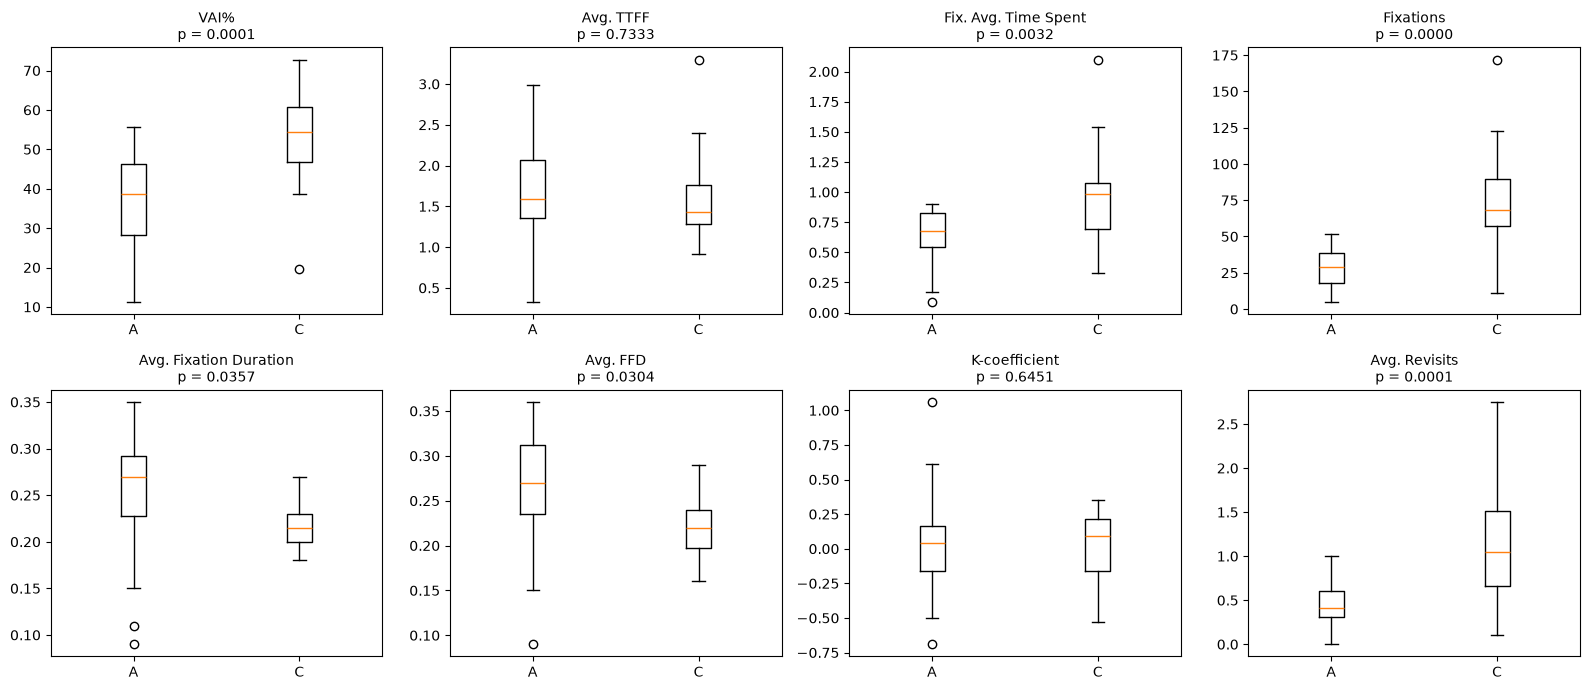

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, m in zip(axes.ravel(), metrics):
    ax.boxplot([a[m].dropna(), c[m].dropna()])
    ax.set_xticklabels(["A", "C"])
    p = results.loc[results["metric"] == m, "p"].iloc[0]
    ax.set_title(f"{m}\np = {p:.4f}", fontsize=10)
plt.tight_layout()
plt.show()